# Hallmarks pathway coverage

💡 **Environment:** `clamp-analyses`  

Pathway coverage analysis for Hallmarks models across random-sampling settings.

In [1]:
library(here)
library(ggplot2)
library(dplyr)
library(grid)

output_dir <- here("output/03_model_biology/00_archs4/00_pathway_coverage/00_hall_coverage")

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title = element_text(size = 24, colour = "black"),
      axis.title.y = element_text(margin = margin(r = 18)),
      axis.text = element_text(size = 18, colour = "black"),
      axis.line = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor = element_blank(),
      legend.position = "none",
      plot.title = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(face = "bold", size = 18),
      plot.margin = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Define GetCLAMPPathwayCoverage

In [2]:
GetCLAMPPathwayCoverage <- function(clamp.results, fdr.cutoff = 0.05, auc.cutoff = 0.6) {
  summary.df     <- clamp.results$summary
  input.pathways <- colnames(clamp.results$C)
  num.lvs        <- ncol(clamp.results$U)

  sig.df       <- summary.df[summary.df$FDR < fdr.cutoff & summary.df$AUC > auc.cutoff, ]
  sig.pathways <- unique(sig.df$pathway)
  sig.lvs      <- unique(sig.df$LV)

  list(
    pathway           = length(sig.pathways) / length(input.pathways),
    lv                = length(sig.lvs) / num.lvs,
    sig.pathway.by.lv = length(sig.pathways) / num.lvs
  )
}

## FDR 0.1, AUC 0.6

In [3]:
output_dir <- here("output/03_model_biology/00_archs4/00_pathway_coverage/00_hall_coverage")

model_specs <- list(
  list(coverage = 1,  seed = 1),
  list(coverage = 1,  seed = 2),
  list(coverage = 1,  seed = 3),
  list(coverage = 5,  seed = 1),
  list(coverage = 5,  seed = 2),
  list(coverage = 5,  seed = 3),
  list(coverage = 10,  seed = 1),
  list(coverage = 10,  seed = 2),
  list(coverage = 10,  seed = 3),
  list(coverage = 25,  seed = 1),
  list(coverage = 25,  seed = 2),
  list(coverage = 25,  seed = 3),
  list(coverage = 50,  seed = 1),
  list(coverage = 50,  seed = 2),
  list(coverage = 50,  seed = 3),
  list(coverage = 75,  seed = 1),
  list(coverage = 75,  seed = 2),
  list(coverage = 75,  seed = 3),
  list(coverage = 100,  seed = 1),
  list(coverage = 100,  seed = 2),
  list(coverage = 100,  seed = 3)
)

results <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("hall_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_hall.rds"
  )

  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }

  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.1, auc.cutoff = 0.6)

  data.frame(
    name               = sprintf("hall_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_samples          = ncol(model$B),
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_df <- do.call(rbind, Filter(Negate(is.null), results))
rownames(results_df) <- NULL
print(results_df)

                         name coverage_pct seed n_samples n_input_pathways
1    hall_coverage_rs1_seed_1            1    1      6056             2953
2    hall_coverage_rs1_seed_2            1    2      6056             2953
3    hall_coverage_rs1_seed_3            1    3      6056             2953
4    hall_coverage_rs5_seed_1            5    1     30281             2953
5    hall_coverage_rs5_seed_2            5    2     30281             2953
6    hall_coverage_rs5_seed_3            5    3     30281             2953
7   hall_coverage_rs10_seed_1           10    1     60561             2953
8   hall_coverage_rs10_seed_2           10    2     60561             2953
9   hall_coverage_rs10_seed_3           10    3     60561             2953
10  hall_coverage_rs25_seed_1           25    1    151404             2953
11  hall_coverage_rs25_seed_2           25    2    151404             2953
12  hall_coverage_rs25_seed_3           25    3    151404             2953
13  hall_coverage_rs50_se

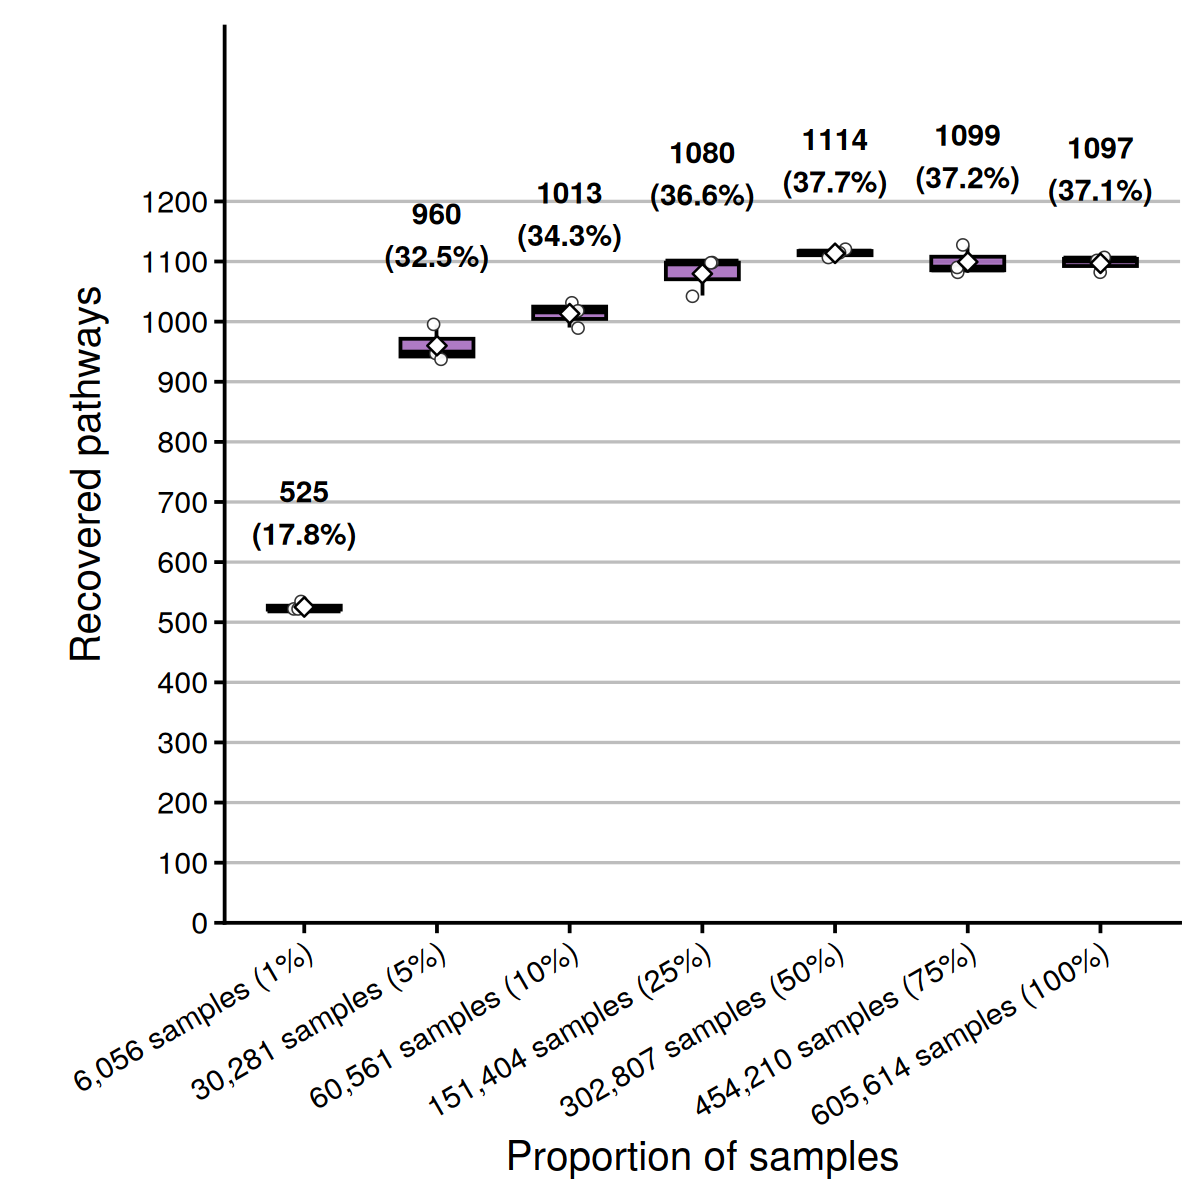

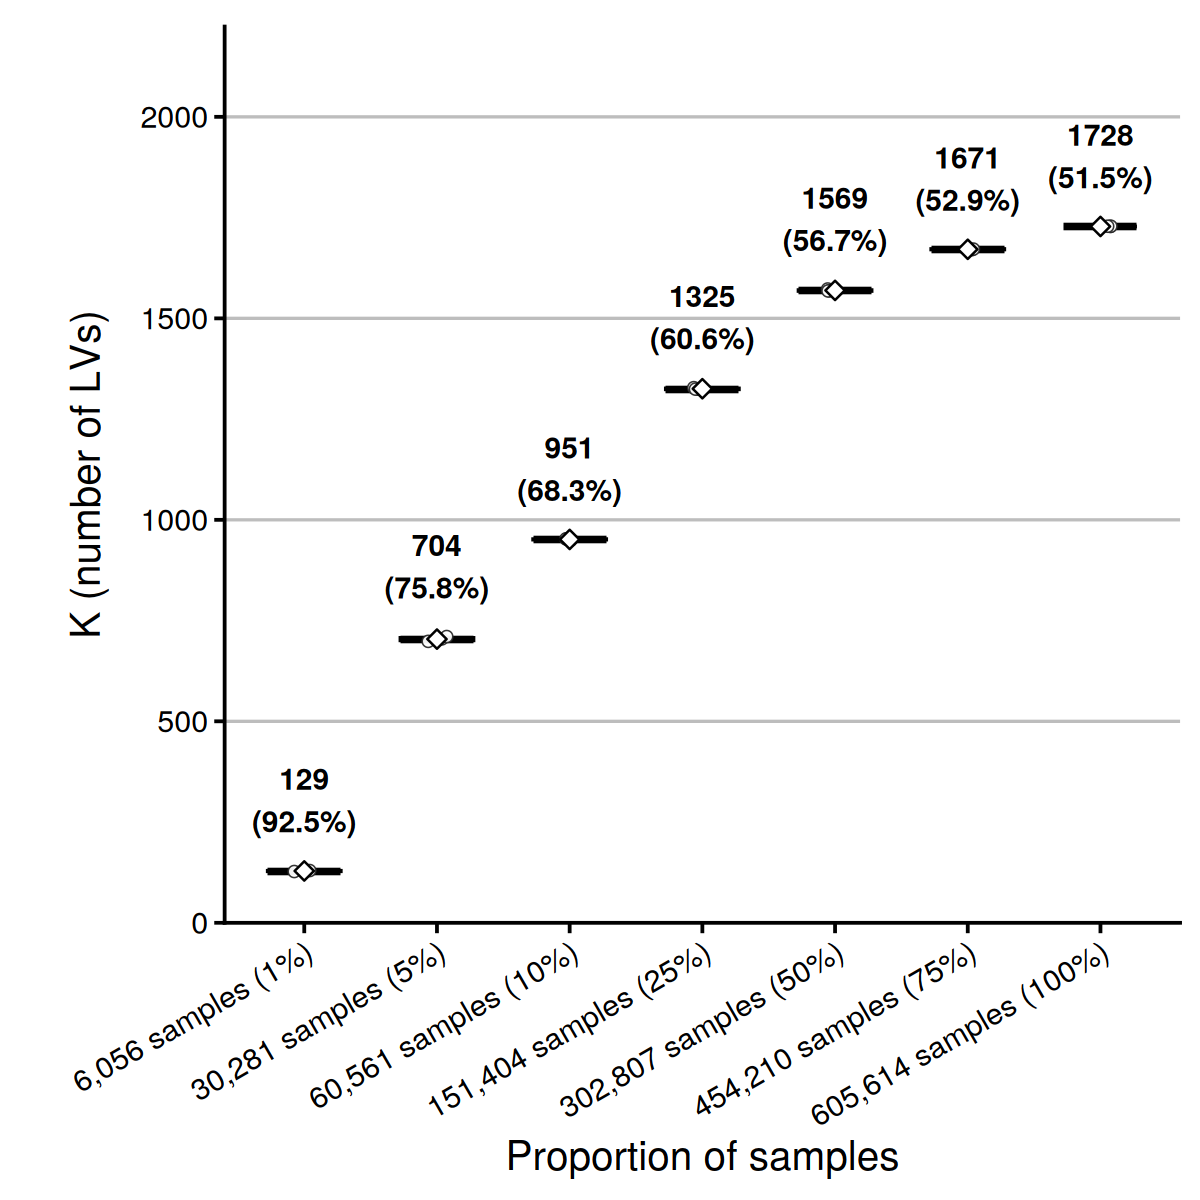

In [4]:
options(repr.plot.width = 10, repr.plot.height = 10)

sample_counts <- results_df %>%
  dplyr::group_by(coverage_pct) %>%
  dplyr::summarise(med_n = round(median(n_samples)), .groups = "drop") %>%
  dplyr::arrange(coverage_pct)

label_map <- setNames(
  paste0(format(sample_counts$med_n, big.mark = ","), " samples (", sample_counts$coverage_pct, "%)"),
  sample_counts$coverage_pct
)

results_df <- results_df %>%
  dplyr::mutate(
    coverage_label = factor(label_map[as.character(coverage_pct)], levels = label_map),
    n_sig_pathways = round(prop_pathway * n_input_pathways)
  )

purple_fill <- "#9b59b6"
pathway_label_offset <- 95
lvs_label_offset <- 95

pathway_label_df <- results_df %>%
  dplyr::group_by(coverage_label) %>%
  dplyr::summarise(
    mean_nsig = mean(n_sig_pathways, na.rm = TRUE),
    mean_prop = mean(prop_pathway * 100, na.rm = TRUE),
    max_y     = max(n_sig_pathways, na.rm = TRUE),
    label_y   = max_y + pathway_label_offset,
    label     = paste0(sprintf("%.0f", mean_nsig), "\n(", sprintf("%.1f", mean_prop), "%)"),
    .groups   = "drop"
  )

lvs_label_df <- results_df %>%
  dplyr::group_by(coverage_label) %>%
  dplyr::summarise(
    mean_y       = mean(n_lvs, na.rm = TRUE),
    mean_prop_lv = mean(prop_lv * 100, na.rm = TRUE),
    max_y        = max(n_lvs, na.rm = TRUE),
    label_y      = max_y + lvs_label_offset,
    label        = paste0(sprintf("%.0f", mean_y), "\n(", sprintf("%.1f", mean_prop_lv), "%)"),
    .groups      = "drop"
  )

p1 <- ggplot(results_df, aes(x = coverage_label, y = n_sig_pathways)) +
  geom_boxplot(width = 0.55, fill = scales::alpha(purple_fill, 0.80), colour = "black",
               linewidth = 0.8, outlier.shape = NA) +
  geom_jitter(width = 0.08, size = 2.8, shape = 21, fill = "white",
              colour = "#2b2b2b", stroke = 0.5, alpha = 0.95) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3.8,
               fill = "white", colour = "black", stroke = 0.8) +
  geom_text(data = pathway_label_df, aes(x = coverage_label, y = label_y, label = label),
            inherit.aes = FALSE, size = 6.2, fontface = "bold", vjust = 0) +
  scale_y_continuous(limits = c(0, NA), breaks = seq(0, 1200, by = 100),
                     expand = expansion(mult = c(0, 0.22))) +
  labs(x = "Proportion of samples", y = "Recovered pathways") +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1))

p2 <- ggplot(results_df, aes(x = coverage_label, y = n_lvs)) +
  geom_boxplot(width = 0.55, fill = scales::alpha(purple_fill, 0.80), colour = "black",
               linewidth = 0.8, outlier.shape = NA) +
  geom_jitter(width = 0.08, size = 2.8, shape = 21, fill = "white",
              colour = "#2b2b2b", stroke = 0.5, alpha = 0.95) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3.8,
               fill = "white", colour = "black", stroke = 0.8) +
  geom_text(data = lvs_label_df, aes(x = coverage_label, y = label_y, label = label),
            inherit.aes = FALSE, size = 6.2, fontface = "bold", vjust = 0) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.22))) +
  labs(x = "Proportion of samples", y = "K (number of LVs)") +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1))

p1
p2

## FDR 0.05

In [5]:
output_dir <- here("output/03_model_biology/00_archs4/00_pathway_coverage/00_hall_coverage")

model_specs <- list(
  list(coverage = 1,  seed = 1),
  list(coverage = 1,  seed = 2),
  list(coverage = 1,  seed = 3),
  list(coverage = 5,  seed = 1),
  list(coverage = 5,  seed = 2),
  list(coverage = 5,  seed = 3),
  list(coverage = 10,  seed = 1),
  list(coverage = 10,  seed = 2),
  list(coverage = 10,  seed = 3),
  list(coverage = 25,  seed = 1),
  list(coverage = 25,  seed = 2),
  list(coverage = 25,  seed = 3),
  list(coverage = 50,  seed = 1),
  list(coverage = 50,  seed = 2),
  list(coverage = 50,  seed = 3),
  list(coverage = 75,  seed = 1),
  list(coverage = 75,  seed = 2),
  list(coverage = 75,  seed = 3),
  list(coverage = 100,  seed = 1),
  list(coverage = 100,  seed = 2),
  list(coverage = 100,  seed = 3) 
)

results <- lapply(model_specs, function(spec) {
  path <- file.path(
    output_dir,
    sprintf("hall_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    "CLAMPfull_hall.rds"
  )

  if (!file.exists(path)) {
    warning("File not found: ", path)
    return(NULL)
  }

  model    <- readRDS(path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = 0.05, auc.cutoff = 0)

  data.frame(
    name               = sprintf("hall_coverage_rs%d_seed_%d", spec$coverage, spec$seed),
    coverage_pct       = spec$coverage,
    seed               = spec$seed,
    n_samples          = ncol(model$B),
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_df <- do.call(rbind, Filter(Negate(is.null), results))
rownames(results_df) <- NULL
print(results_df)

                         name coverage_pct seed n_samples n_input_pathways
1    hall_coverage_rs1_seed_1            1    1      6056             2953
2    hall_coverage_rs1_seed_2            1    2      6056             2953
3    hall_coverage_rs1_seed_3            1    3      6056             2953
4    hall_coverage_rs5_seed_1            5    1     30281             2953
5    hall_coverage_rs5_seed_2            5    2     30281             2953
6    hall_coverage_rs5_seed_3            5    3     30281             2953
7   hall_coverage_rs10_seed_1           10    1     60561             2953
8   hall_coverage_rs10_seed_2           10    2     60561             2953
9   hall_coverage_rs10_seed_3           10    3     60561             2953
10  hall_coverage_rs25_seed_1           25    1    151404             2953
11  hall_coverage_rs25_seed_2           25    2    151404             2953
12  hall_coverage_rs25_seed_3           25    3    151404             2953
13  hall_coverage_rs50_se

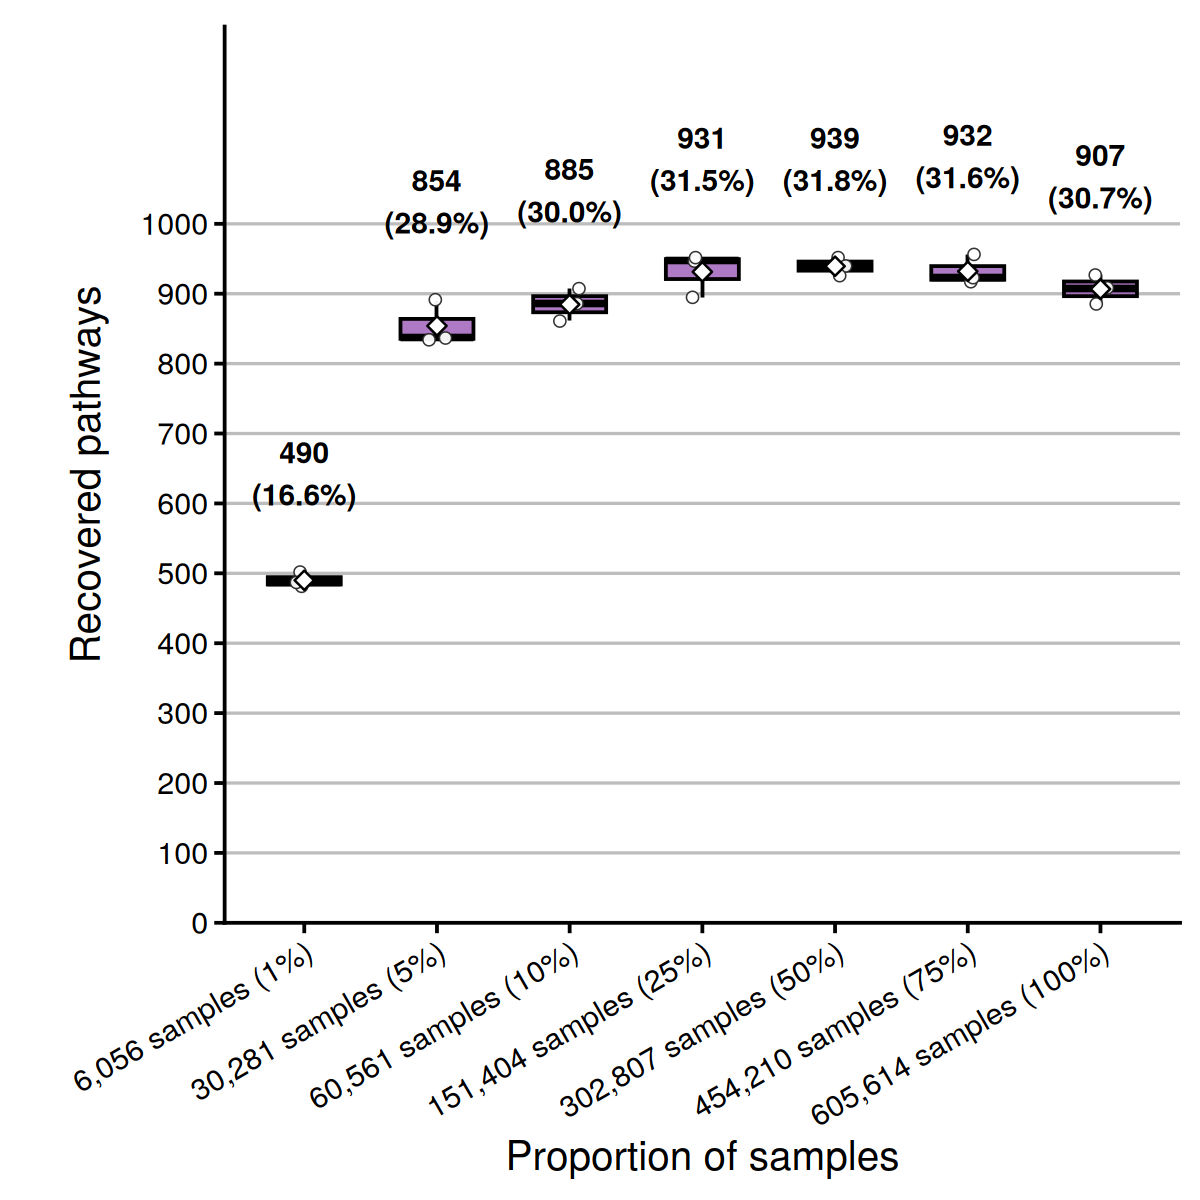

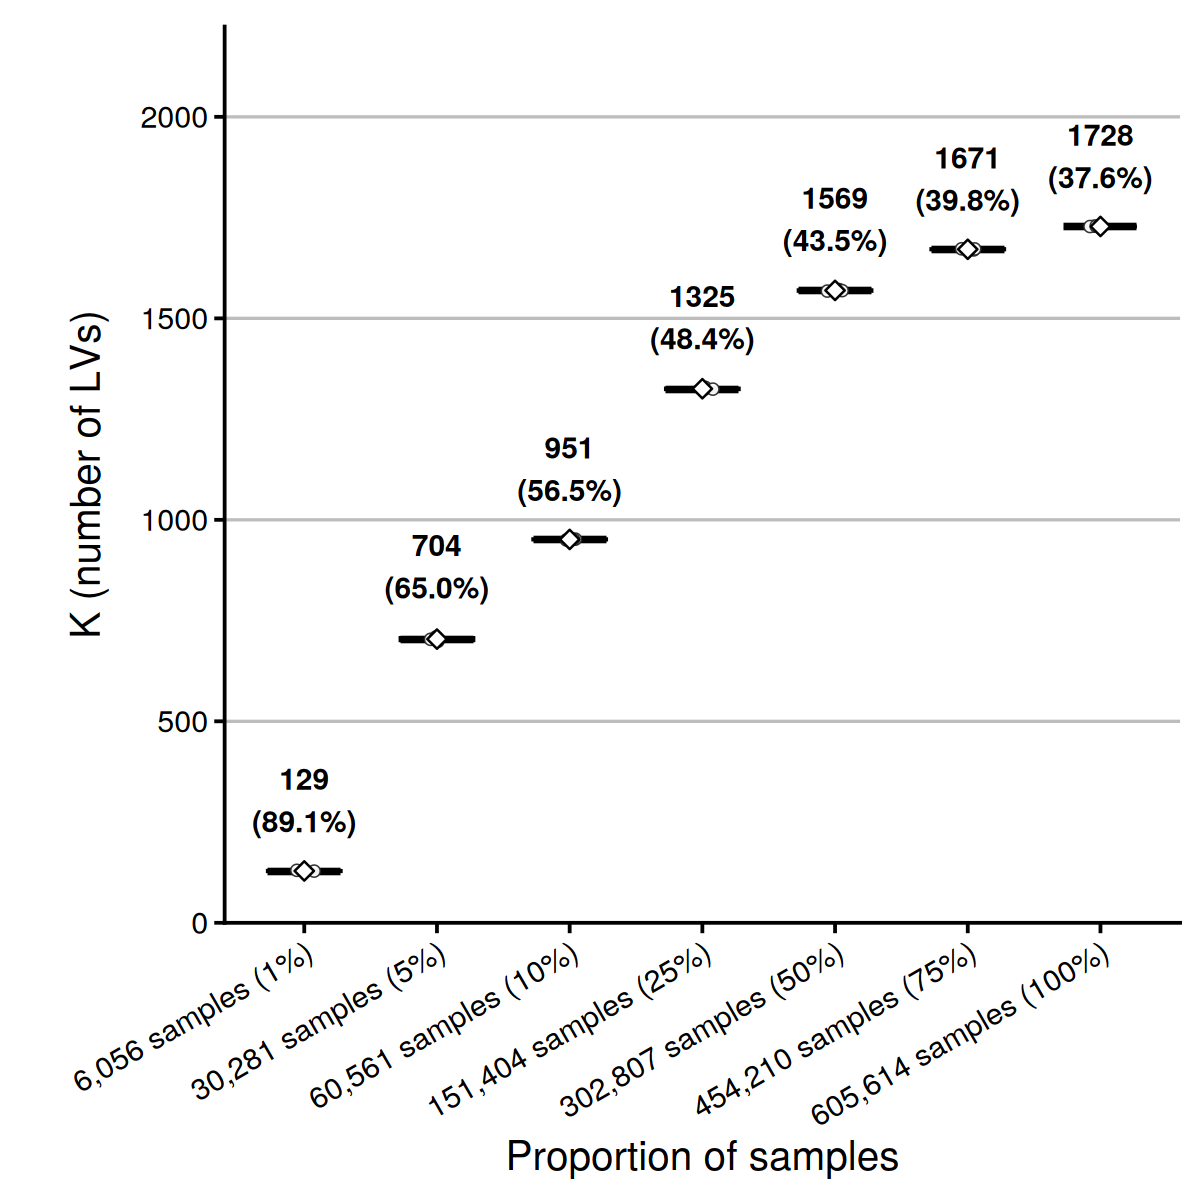

In [6]:
options(repr.plot.width = 10, repr.plot.height = 10)

sample_counts <- results_df %>%
  dplyr::group_by(coverage_pct) %>%
  dplyr::summarise(med_n = round(median(n_samples)), .groups = "drop") %>%
  dplyr::arrange(coverage_pct)

label_map <- setNames(
  paste0(format(sample_counts$med_n, big.mark = ","), " samples (", sample_counts$coverage_pct, "%)"),
  sample_counts$coverage_pct
)

results_df <- results_df %>%
  dplyr::mutate(
    coverage_label = factor(label_map[as.character(coverage_pct)], levels = label_map),
    n_sig_pathways = round(prop_pathway * n_input_pathways)
  )

purple_fill <- "#9b59b6"
pathway_label_offset <- 95
lvs_label_offset <- 95

pathway_label_df <- results_df %>%
  dplyr::group_by(coverage_label) %>%
  dplyr::summarise(
    mean_nsig = mean(n_sig_pathways, na.rm = TRUE),
    mean_prop = mean(prop_pathway * 100, na.rm = TRUE),
    max_y     = max(n_sig_pathways, na.rm = TRUE),
    label_y   = max_y + pathway_label_offset,
    label     = paste0(sprintf("%.0f", mean_nsig), "\n(", sprintf("%.1f", mean_prop), "%)"),
    .groups   = "drop"
  )

lvs_label_df <- results_df %>%
  dplyr::group_by(coverage_label) %>%
  dplyr::summarise(
    mean_y       = mean(n_lvs, na.rm = TRUE),
    mean_prop_lv = mean(prop_lv * 100, na.rm = TRUE),
    max_y        = max(n_lvs, na.rm = TRUE),
    label_y      = max_y + lvs_label_offset,
    label        = paste0(sprintf("%.0f", mean_y), "\n(", sprintf("%.1f", mean_prop_lv), "%)"),
    .groups      = "drop"
  )

p1 <- ggplot(results_df, aes(x = coverage_label, y = n_sig_pathways)) +
  geom_boxplot(width = 0.55, fill = scales::alpha(purple_fill, 0.80), colour = "black",
               linewidth = 0.8, outlier.shape = NA) +
  geom_jitter(width = 0.08, size = 2.8, shape = 21, fill = "white",
              colour = "#2b2b2b", stroke = 0.5, alpha = 0.95) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3.8,
               fill = "white", colour = "black", stroke = 0.8) +
  geom_text(data = pathway_label_df, aes(x = coverage_label, y = label_y, label = label),
            inherit.aes = FALSE, size = 6.2, fontface = "bold", vjust = 0) +
  scale_y_continuous(limits = c(0, NA), breaks = seq(0, 1000, by = 100),
                     expand = expansion(mult = c(0, 0.22))) +
  labs(x = "Proportion of samples", y = "Recovered pathways") +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1))

p2 <- ggplot(results_df, aes(x = coverage_label, y = n_lvs)) +
  geom_boxplot(width = 0.55, fill = scales::alpha(purple_fill, 0.80), colour = "black",
               linewidth = 0.8, outlier.shape = NA) +
  geom_jitter(width = 0.08, size = 2.8, shape = 21, fill = "white",
              colour = "#2b2b2b", stroke = 0.5, alpha = 0.95) +
  stat_summary(fun = mean, geom = "point", shape = 23, size = 3.8,
               fill = "white", colour = "black", stroke = 0.8) +
  geom_text(data = lvs_label_df, aes(x = coverage_label, y = label_y, label = label),
            inherit.aes = FALSE, size = 6.2, fontface = "bold", vjust = 0) +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.22))) +
  labs(x = "Proportion of samples", y = "K (number of LVs)") +
  coord_cartesian(clip = "off") +
  theme_ng() +
  theme(axis.text.x = element_text(angle = 30, hjust = 1, vjust = 1))

p1
p2

In [7]:
PANEL_DIR_FIG4 <- here('output/99_panels/fig4')
dir.create(PANEL_DIR_FIG4, recursive = TRUE, showWarnings = FALSE)

export_df <- results_df %>%
  dplyr::select(name, coverage_pct, seed, n_samples, n_input_pathways,
                n_lvs, prop_pathway, prop_lv, sig_pathway_per_lv, n_sig_pathways)

write.csv(export_df, file.path(PANEL_DIR_FIG4, 'hall_pathway_coverage.csv'), row.names = FALSE)
message("Saved hall_pathway_coverage.csv to ", PANEL_DIR_FIG4)

Saved hall_pathway_coverage.csv to /home/msubirana/Documents/pivlab/clamp-analyses/output/99_panels/fig4

